# SHRED on ME4OH full-field OFAM3 SST data

Note: Assumptions as of 30/06/26
- OFAM3 data is stored for Thursdays across the 1979-2014 time period.
- Pending confirmation from the ME4OH team, I have assumed that the data is the full-field SST values generated by the simulator model (OFAM3) averaged across a calendar week

In [161]:
from collections import Counter

# Third-party imports
import matplotlib.pyplot as plt
import mpl_scatter_density # adds projection='scatter_density'
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from skimage.metrics import structural_similarity as SSI
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

# Local imports
import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py 
from Data.preprocess_sst_ofam3_shred import create_shred_sequences, load_files, split_ordered_data
from Data.preprocess_sst_ofam3_shred import NA_DATA_PATH
from Data.load_sst_en411_data import crop_df_to_area
from helper_functions.evaluation import mask_array_by_lat_long, area_weighted_sst_mean, ssi_by_image
from plotting_functions import plot_sst_map, plot_compare_sst_recon

np.random.seed(42)

colours = ["#1589e8", "#ffb000", "#dc267f", "#631ff3", "#fe5100"]  # IBM colourblind palette

## SHRED preprocessing

In [2]:
# Experiment 1: 5 randomly located sensors
# num_sensors = 5
# lags = 52

# Experiment 2: average number of sensors per week in ME4OH SST dataset is 1059 (increases over time)
num_sensors = 1059
lags = 52

In [3]:
# Load and reformat data
data, dates, lats, longs = load_files()

Loading data: 100%|██████████| 1878/1878 [00:10<00:00, 185.87it/s]


In [4]:
print("Preprocessing data...")
train_data, val_data, test_data, test_dates = split_ordered_data(data, dates)

# Normalise data
sc = MinMaxScaler()
sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
train_transformed = sc.transform(train_data)  
val_transformed = sc.transform(val_data)
test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
sensor_coords=(longs[sensor_locations], lats[sensor_locations])
# print(f"Sensor location indexes will be: {sensor_locations}")

# Build sequences
train_dataset = create_shred_sequences(train_transformed, sensor_locations, lags=lags)
val_dataset = create_shred_sequences(val_transformed, sensor_locations, lags=lags)
test_dataset = create_shred_sequences(test_transformed, sensor_locations, lags=lags)

# Get dates corresponding to the predictions made by the model
test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

Preprocessing data...


## Train + test SHRED model

In [ ]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# shred = models.SHRED(num_sensors, len(lats), hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
# validation_errors = models.fit(shred, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

In [ ]:
# test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
# test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
# print('Test Reconstruction Error: ')
# print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

In [ ]:
# np.save(f"Reconstructions/recons_n{num_sensors}_l{lags}", test_recons)
# np.save(f"Reconstructions/truth_n{num_sensors}_l{lags}", test_ground_truth)

## Evaluation

In [5]:
test_recons = np.load(f"Reconstructions/recons_n{num_sensors}_l{lags}.npy")
test_ground_truth = np.load(f"Reconstructions/truth_n{num_sensors}_l{lags}.npy")

In [ ]:
for i in np.random.choice(range(len(test_recons)), 1):
    recon_df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": test_recons[i]
    })
    true_df = pd.read_csv(f"{NA_DATA_PATH}{test_lag_dates[i]}.csv")
    print(f"Date: {test_lag_dates[i]}")
    plot_compare_sst_recon(recon_df, true_df, area="NA")
    plot_compare_sst_recon(recon_df, true_df, area="NA", sensor_coords=sensor_coords)

In [ ]:
# plot_sst_map(recon_df, test_lag_dates[i], min_sst=min(recon_df.SST), max_sst=max(recon_df.SST), area='NA', sensor_coords=sensor_coords)

In [ ]:
# plot_sst_map(true_df, date, min(true_df.SST), max(true_df.SST), area='NA')

### Metrics
Structural Similarity Index: [[1]](https://scikit-image.org/docs/stable/api/skimage.metrics.html#skimage.metrics.structural_similarity) [[2]](https://ieeexplore.ieee.org/document/4775883)

### NA basin

In [ ]:
rmse = np.sqrt(MSE(y_pred=test_recons, y_true=test_ground_truth))
mae = MAE(y_pred=test_recons, y_true=test_ground_truth)
r2 = r2_score(y_pred=test_recons, y_true=test_ground_truth)
print(f"RMSE:\t{rmse:.3f}")
print(f"MAE:\t{mae:.3f}")
print(f"R2:\t{r2:.3f}")

In [ ]:
ssi = np.mean([SSI(test_ground_truth[i], test_recons[i], 
                   data_range=(max(test_recons[i].max(), test_ground_truth[i].max()) - min(test_recons[i].min(), test_ground_truth[i].min())))
                   for i in range(len(test_recons))])
print(f"Average SSI:\t{ssi:.3f}")

In [ ]:
ssi_by_images = ssi_by_image(test_recons[0:2], test_ground_truth[0:2], lats, longs, plot_images=True)
# ssi_by_images_mean = np.mean(ssi_by_images)
# print(f"Average SSI (by images):\t{ssi_by_images_mean:.3f}")

#### Gulf-Stream region

In [ ]:
GS_test_data = mask_array_by_lat_long(test_recons, lats, longs)
GS_truth_data = mask_array_by_lat_long(test_ground_truth, lats, longs)
GS_test_data = [d[~np.isnan(d)] for d in GS_test_data]
GS_truth_data = [d[~np.isnan(d)] for d in GS_truth_data]

In [ ]:
rmse = np.sqrt(MSE(y_pred=GS_test_data, y_true=GS_truth_data))
mae = MAE(y_pred=GS_test_data, y_true=GS_truth_data)
r2 = r2_score(y_pred=GS_test_data, y_true=GS_truth_data)
print(f"RMSE:\t{rmse:.3f}")
print(f"MAE:\t{mae:.3f}")
print(f"R2:\t{r2:.3f}")

In [ ]:
ssi = np.mean([SSI(GS_truth_data[i], GS_test_data[i], data_range=test_recons[i].max() -  test_recons[i].min()) for i in range(len(test_recons))])
print(f"Average SSI:\t{ssi:.3f}")

### Density scatter plot

In [ ]:
# https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density

# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

def using_mpl_scatter_density(fig, x, y):
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    density = ax.scatter_density(x, y, cmap=white_viridis)
    ax.set_xlim(-5, 35)
    ax.set_ylim(-5, 35)
    fig.colorbar(density, label='Number of points per pixel')

fig = plt.figure()
x = test_ground_truth.reshape(-1)
y = test_recons.reshape(-1)
using_mpl_scatter_density(fig, x, y)
plt.plot([-5, 35], [-5, 35], ':', lw=1, c='r')
plt.xlabel("Observed SST ($\\degree$C)")
plt.ylabel("Reconstructed SST ($\\degree$C)")
plt.show()

In [ ]:
fig = plt.figure()
i = 177
# plt.scatter(test_ground_truth[i], test_recons[i], alpha=0.25)
using_mpl_scatter_density(fig, test_ground_truth[i].reshape(-1), test_recons[i].reshape(-1))
plt.plot([-5, 35], [-5, 35], ':', lw=1, c='r')
plt.xlabel("Observed SST ($\\degree$C)")
plt.ylabel("Reconstructed SST ($\\degree$C)")
plt.title(f"{test_lag_dates[i]}")

In [ ]:
# lats = np.array([20.0, 31.0, 33.0, 50.0, 55.0])
# longs = np.array([-80.0, -80.0, -34.0, -34.0, -34.0])
# data = np.array([[24.0, 25.0, 26.0, 27.0, 28.0], [24.0, 25.0, 26.0, 27.0, 28.0], [24.0, 25.0, 26.0, 27.0, 28.0]])
# data = mask_array_by_lat_long(test_recons, lats, longs)

### Regional integral of SST (area weighted mean)

In [7]:
test_sst_mean = area_weighted_sst_mean(test_recons, lats, longs)
truth_sst_mean = area_weighted_sst_mean(test_ground_truth, lats, longs)

In [73]:
sst_mean_df = pd.DataFrame({
    "Date": test_lag_dates,
    "SHRED": test_sst_mean,
    "Truth": truth_sst_mean
})
sst_rolling_df = pd.DataFrame({
    "Date": test_lag_dates,
    "SHRED": sst_mean_df.SHRED.rolling(lags).mean(),
    "Truth": sst_mean_df.Truth.rolling(lags).mean()
})
sst_mean_df = sst_mean_df.set_index("Date")
sst_rolling_df = sst_rolling_df.set_index("Date")

Text(0, 0.5, 'Mean SST ($\\degree$C)')

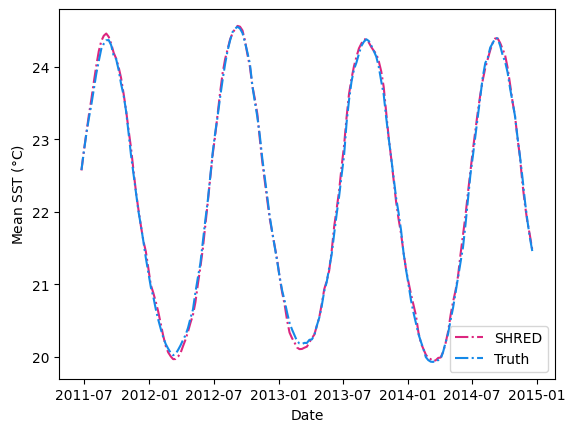

In [80]:
sst_mean_df[['SHRED','Truth']].plot(colormap=ListedColormap(["#dc267f","#1589e8"]), ls='-.')
plt.ylabel("Mean SST ($\\degree$C)")

Text(0, 0.5, 'Smoothed mean SST ($\\degree$C)')

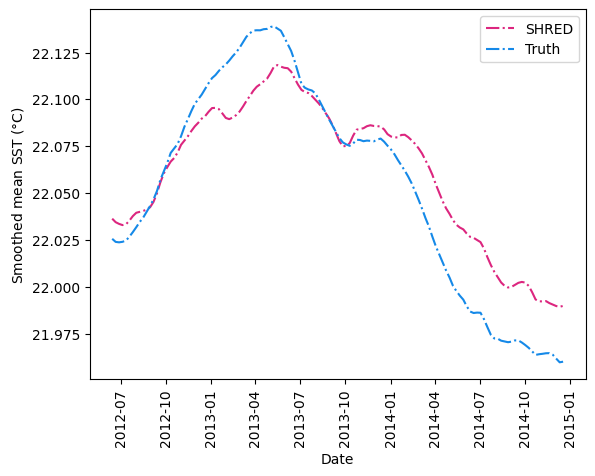

In [81]:
sst_rolling_df[['SHRED', 'Truth']].plot(colormap=ListedColormap(["#dc267f","#1589e8"]), ls='-.')
plt.xticks(rotation=90)
plt.ylabel("Smoothed mean SST ($\\degree$C)")

### Zonally integrated average SST
Thoughts: not really telling us anything

Text(0, 0.5, 'Latitude')

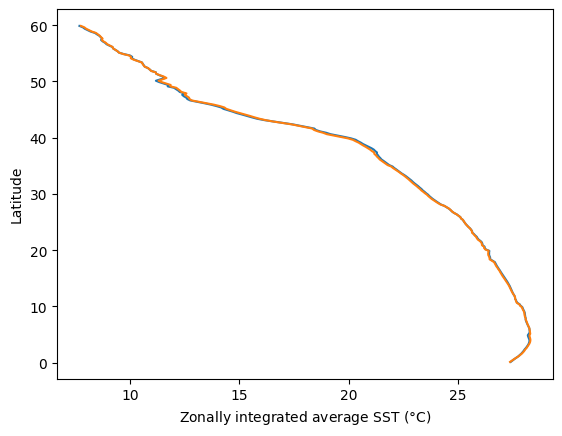

In [124]:
for data in [test_recons, test_ground_truth]:
    latitude_avg_sst = np.array([pd.Series(data_for_date).groupby(lats).mean().to_numpy() for data_for_date in data])
    avg_all_time_lat_avg = np.array([np.mean([data_for_date[j] for data_for_date in latitude_avg_sst]) for j in range(len(latitude_avg_sst[0]))])

    plt.plot(avg_all_time_lat_avg, np.unique(lats))
plt.xlabel('Zonally integrated average SST ($\\degree$C)')
plt.ylabel('Latitude')

### Difference between test truth and reconstructions 
#### Plots

Date: 2011-07-14


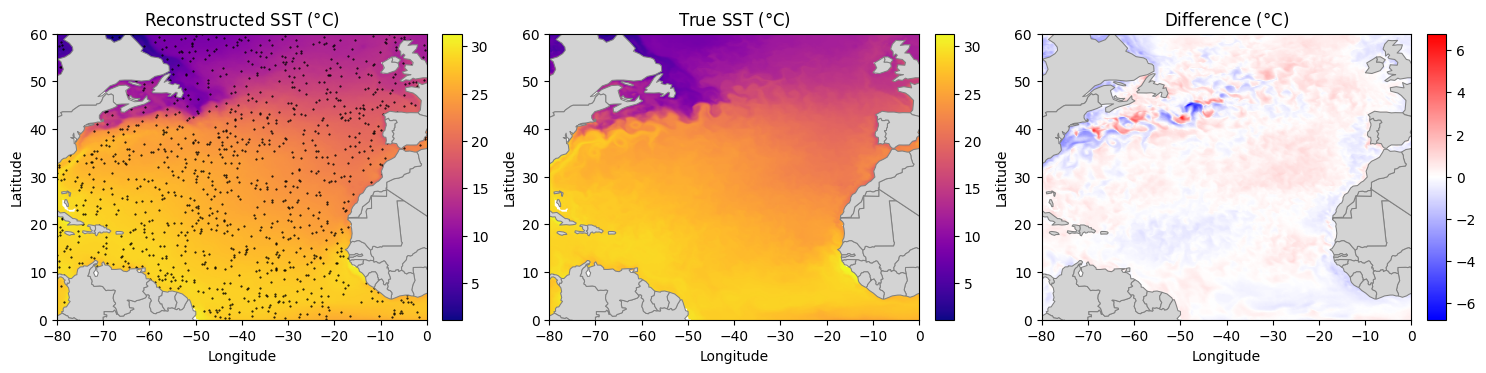

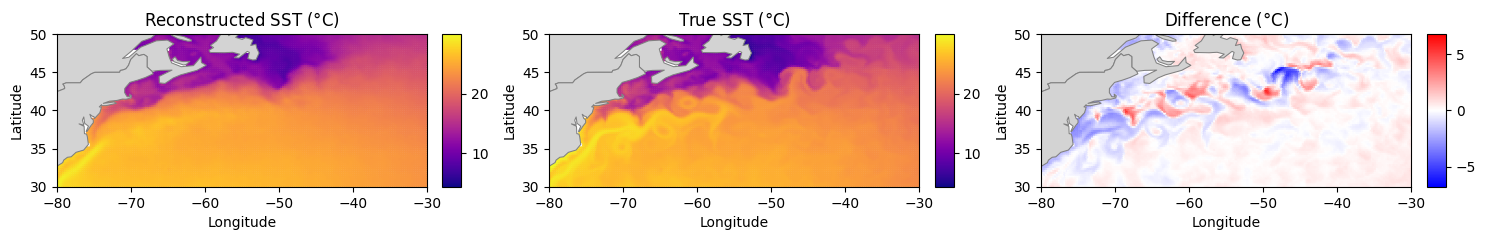

In [89]:
difference = test_recons - test_ground_truth
for i in [3]:# range(0, len(test_recons), 10):  # np.random.choice(range(len(test_recons)), 1):
    diff_df = pd.DataFrame({
            "Latitude": lats,
            "Longitude": longs,
            "SST": difference[i]
        })
    recon_df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": test_recons[i]
    })
    true_df = pd.read_csv(f"{NA_DATA_PATH}{test_lag_dates[i]}.csv")
    # plot_sst_map(diff_df, title=f"Difference map for {test_dates[i]}", min_sst=-5, max_sst=5, area="NA", cmap='bwr')
    print(f"Date: {test_lag_dates[i]}")
    plot_compare_sst_recon(recon_df, true_df, diff_data=diff_df, area="NA", sensor_coords=sensor_coords)

    gs_recon_df = crop_df_to_area(recon_df, "GS", "Latitude")
    gs_true_df = crop_df_to_area(true_df, "GS", "Latitude")
    gs_diff_df = crop_df_to_area(diff_df, "GS", "Latitude")
    
    plot_compare_sst_recon(gs_recon_df, gs_true_df, diff_data=gs_diff_df, area='GS')

#### Zonally integrated average difference 
i.e. average difference averaged for each timestep; plotted against latitude (no weighting by area needed, because each square in latitude band has same area?)

OR could scale by area by doing lat_band/total_area????

In [125]:
latitude_avg_diffs = np.array([pd.Series(diff).groupby(lats).mean().to_numpy() for diff in difference])
avg_all_time_lat_avg_diffs = np.array([np.mean([time[j] for time in latitude_avg_diffs]) for j in range(len(latitude_avg_diffs[0]))])

In [134]:
latitude_avg_diffs.shape

(183, 240)

Text(0, 0.5, 'Latitude')

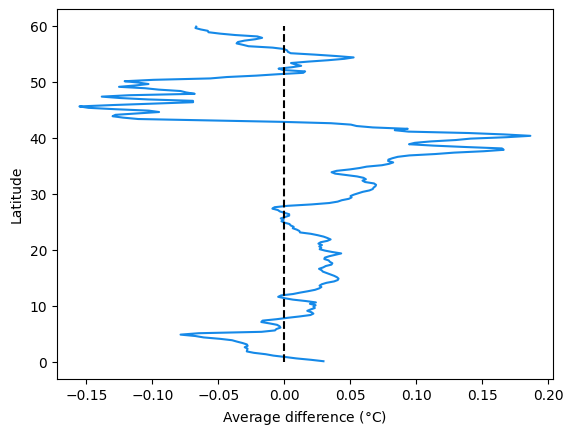

In [164]:
plt.plot(avg_all_time_lat_avg_diffs, np.unique(lats), c=colours[0])
plt.vlines(0, 0, 60, colors=['k'], linestyles=['--'])
plt.xlabel('Average difference ($\\degree$C)')
plt.ylabel('Latitude')

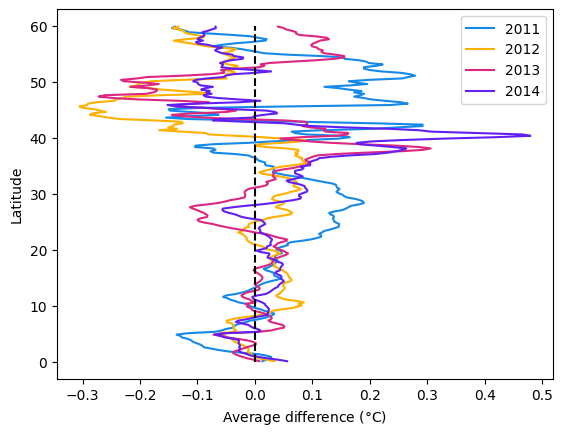

In [163]:
years = [int(date.year) for date in test_lag_dates]
year_labels = np.unique(years)
diff_by_years = np.array([[time[j] for time in latitude_avg_diffs] for j in range(len(latitude_avg_diffs[0]))])
latitude_avg_diffs_avg_by_year = np.array([pd.Series(d).groupby(years).mean().to_numpy() for d in diff_by_years])

for i in range(len(year_labels)):
    lat_for_year = [lat[i] for lat in latitude_avg_diffs_avg_by_year]
    plt.plot(lat_for_year, np.unique(lats), label=year_labels[i], c=colours[i])
plt.vlines(0, 0, 60, colors=['k'], linestyles=['--'])
plt.xlabel('Average difference ($\\degree$C)')
plt.ylabel('Latitude')
plt.legend()

#### Average difference between reconstruction and truth across whole test set

0.010570057


Text(0.5, 0, 'Reconstruction date')

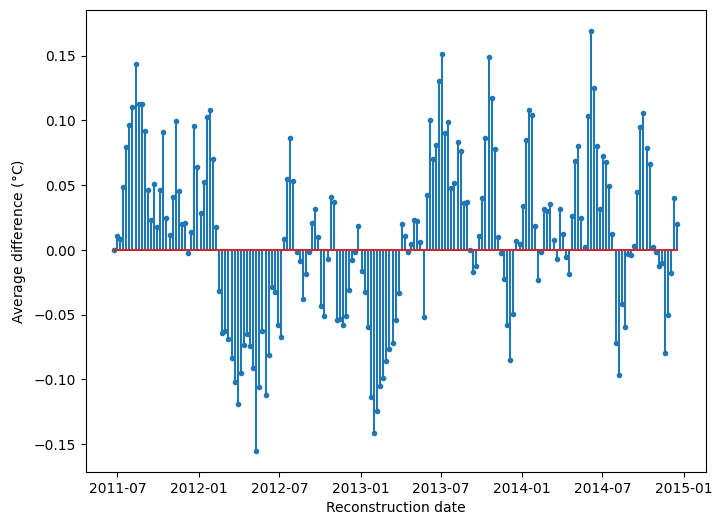

In [110]:
avg_difference = [np.mean(d) for d in difference]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(test_lag_dates, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')

In [ ]:
# For Gulf Stream only:
GS_data = mask_array_by_lat_long(difference, lats, longs)
GS_data = [d[~np.isnan(d)] for d in GS_data]

In [ ]:
avg_difference = [np.mean(d) for d in GS_data]
avg_all_time_difference = np.mean(avg_difference)
print(avg_all_time_difference)
plt.figure(figsize=(8,6))
plt.stem(test_lag_dates, avg_difference, markerfmt='.')
plt.ylabel('Average difference ($\\degree$C)')
plt.xlabel('Reconstruction date')

### Differences between test reconstructions
Verifying that not just getting identical reconstructions
- Not every point in scatter plot is 0 - so there is difference!

Also see: clear seasonality in the generations being produced!
- Sensible that there's a clear difference when spring to autumn are compared

In [ ]:
# avg_diff = []
# date1 = []
# date2 = []
# for i in range(len(test_recons)):
#     for j in range(len(test_recons)):
#         date1.append(test_dates[i])
#         date2.append(test_dates[j])
#         avg_diff.append(np.mean(test_recons[i] - test_recons[j]))

# diff_df = pd.DataFrame({
#     "Date 1": date1,
#     "Date 2": date2,
#     "Average difference ($\\degree$C)": avg_diff
# })

In [ ]:
# s = diff_df.plot.scatter(x="Date 1", y="Date 2", c="Average difference ($\\degree$C)", cmap='rainbow')
# plt.xticks(rotation=90)
# plt.grid()

In [ ]:
# Santity check that all reconstructions aren't identical
bool_check = [[np.array_equal(recon1,recon2) for recon2 in test_recons] for recon1 in test_recons]

In [ ]:
# Check that only ever 1 True value (on diagonal)
Counter([Counter(row) == Counter({False: 182, True: 1}) for row in bool_check])
# Expected output: Counter({True: 183})

In [ ]:
# Check all diagonals are true
Counter(np.diag(bool_check))
# Expected output: Counter({True: 183})

In [ ]:
plt.matshow(bool_check)
# Expected output: Only diagonal of matrix is True (yellow), rest is False (purple)

### Changing numbers of sensors
Run training and evaluating halves of shred_ofam3sst_static_changing_sensor_nums.py script first

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Data.preprocess_sst_ofam3_shred import load_files
from plotting_functions import set_area


In [ ]:
with open("Reconstructions/change_num_sensors/v2/eval_metric_results.json", 'r') as f:
    data = json.load(f)

In [ ]:
print(data)
        

In [ ]:
# Unpack data dict into NA and GS dataframes
na_df = pd.DataFrame([data[key]['NA'] for key in sorted(data.keys(), key=lambda x: int(x))], 
                      index=[int(key) for key in sorted(data.keys(), key=lambda x: int(x))])
gs_df = pd.DataFrame([data[key]['GS'] for key in sorted(data.keys(), key=lambda x: int(x))], 
                      index=[int(key) for key in sorted(data.keys(), key=lambda x: int(x))])

In [ ]:
colours = {  # IBM colourblind palette
    "RMSE": "#1589e8",
    "MAE": "#dc267f",
    "R2": "#631ff3",
    "Average SSI": "#fe5100",
    "Average all time diff": "#ffb000"
}

In [ ]:
for col in na_df.columns:
    plt.plot(na_df.index, na_df[col], label=col, c=colours[col])
plt.xlabel("Number of sensors")
plt.ylabel("Metric value")
plt.legend()

In [ ]:
for col in gs_df.columns:
    plt.plot(gs_df.index, gs_df[col], label=col, c=colours[col])
plt.xlabel("Number of sensors")
plt.ylabel("Metric value")
plt.legend()

In [ ]:
def plot_sensors(sensor_coords, area="NA", background=True, title=None):
        if area=="world":
            fig, ax = plt.subplots(figsize=(18, 9))
        else:
            fig, ax = plt.subplots(figsize=(12, 6))

        ax.scatter(sensor_coords[0], sensor_coords[1], marker='.', c='k', s=1)

        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        if background:
            ax.set_facecolor("lightblue")

        set_area(ax, area)

        plt.title(title)
        # plt.savefig(f"images/sst_{area}_map_{title}.png")
        plt.show()
        plt.close()

In [ ]:
# data, dates, lats, longs = load_files()

# for num_sensors in na_df.index:
#     sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
#     sensor_coords=(longs[sensor_locations], lats[sensor_locations])
#     plot_sensors(sensor_coords)